### Alpha Vantage

https://www.alphavantage.co/documentation/

#### Pegando cotações semanais - JSON

In [11]:
import requests

key = 'IY6ECQG3NEIV1SMO' #pessoal

# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_WEEKLY_ADJUSTED&symbol=GOOG&apikey={key}'
r = requests.get(url)
data = r.json()

display(data)

{'Meta Data': {'1. Information': 'Weekly Adjusted Prices and Volumes',
  '2. Symbol': 'GOOG',
  '3. Last Refreshed': '2025-10-15',
  '4. Time Zone': 'US/Eastern'},
 'Weekly Adjusted Time Series': {'2025-10-15': {'1. open': '241.0300',
   '2. high': '252.7600',
   '3. low': '240.7500',
   '4. close': '251.7100',
   '5. adjusted close': '251.7100',
   '6. volume': '46218422',
   '7. dividend amount': '0.0000'},
  '2025-10-10': {'1. open': '245.7800',
   '2. high': '252.2000',
   '3. low': '236.6850',
   '4. close': '237.4900',
   '5. adjusted close': '237.4900',
   '6. volume': '88081503',
   '7. dividend amount': '0.0000'},
  '2025-10-03': {'1. open': '248.2750',
   '2. high': '251.6483',
   '3. low': '239.2000',
   '4. close': '246.4500',
   '5. adjusted close': '246.4500',
   '6. volume': '110265001',
   '7. dividend amount': '0.0000'},
  '2025-09-26': {'1. open': '254.7800',
   '2. high': '256.3100',
   '3. low': '241.6500',
   '4. close': '247.1800',
   '5. adjusted close': '247.180

#### Pegando cotações semanais - CSV

,timestamp,open,high,low,close,adjusted close,volume,dividend amount
0,2025-10-15,241.030,252.7600,240.750,251.71,251.71,46218422,0.0
1,2025-10-10,245.780,252.2000,236.685,237.49,237.49,88081503,0.0
2,2025-10-03,248.275,251.6483,239.200,246.45,246.45,110265001,0.0
3,2025-09-26,254.780,256.3100,241.650,247.18,247.18,88532985,0.0
4,2025-09-19,245.140,256.7000,244.980,255.24,255.24,137703189,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        603 non-null    datetime64[ns]
 1   open             603 non-null    float64       
 2   high             603 non-null    float64       
 3   low              603 non-null    float64       
 4   close            603 non-null    float64       
 5   adjusted close   603 non-null    float64       
 6   volume           603 non-null    int64         
 7   dividend amount  603 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 37.8 KB


None

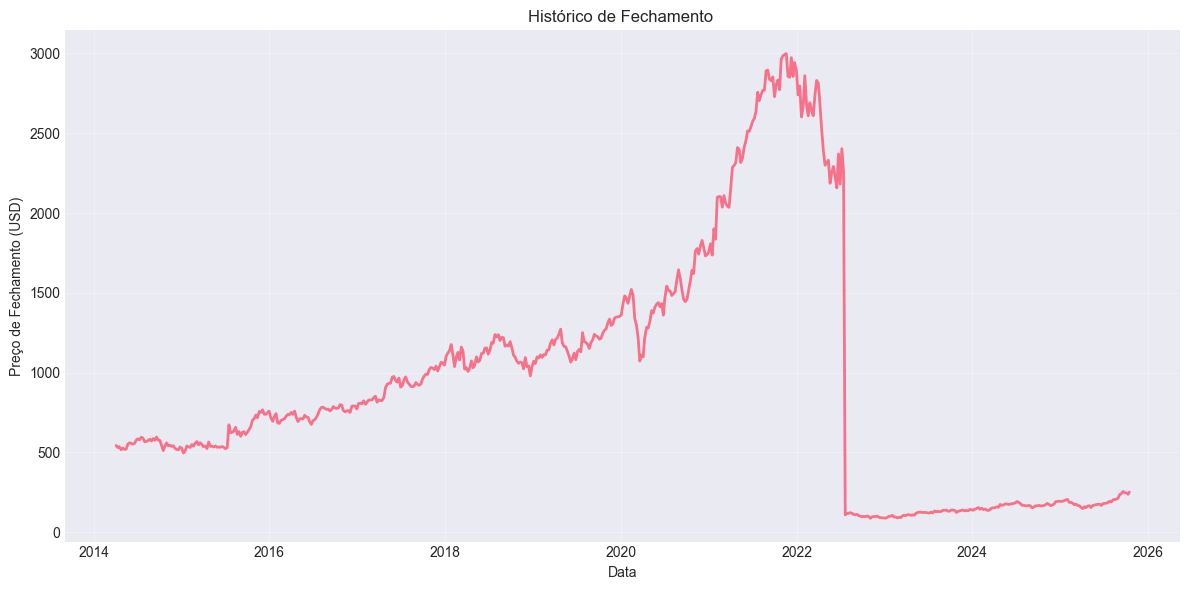

In [12]:
import requests
import pandas as pd
from datetime import datetime

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_WEEKLY_ADJUSTED&symbol=GOOG&apikey={key}&datatype=csv'
r = requests.get(url)
df = pd.read_csv(url)

display(df.head(5))

df['timestamp'] = pd.to_datetime(df['timestamp'])
display(df.info())

df['timestamp_float'] = df['timestamp'].apply(lambda x: x.timestamp())

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['close'], linewidth=2)
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (USD)')
plt.title(f'Histórico de Fechamento ')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cotações

,symbol,open,high,low,price,volume,latestDay,previousClose,change,changePercent,acao
0,ITUB4.SAO,37.32,37.7,37.06,37.45,21328400,2025-10-15,37.45,0.00,0.0000,ITUB4
1,ABEV3.SAO,11.99,12.1,11.91,11.99,28406800,2025-10-15,12.05,-0.06,-0.4979,ABEV3
2,BBAS3.SAO,20.70,20.7,20.23,20.32,59390200,2025-10-15,20.70,-0.38,-1.8357,BBAS3


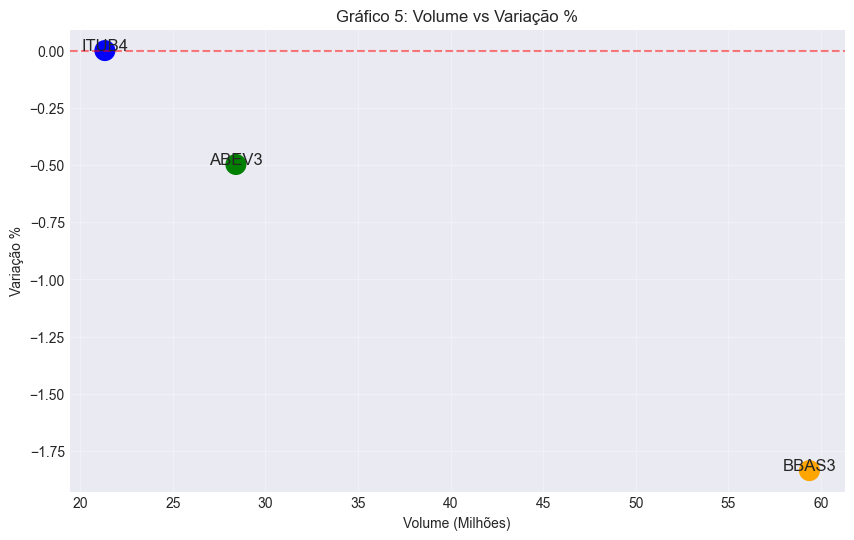

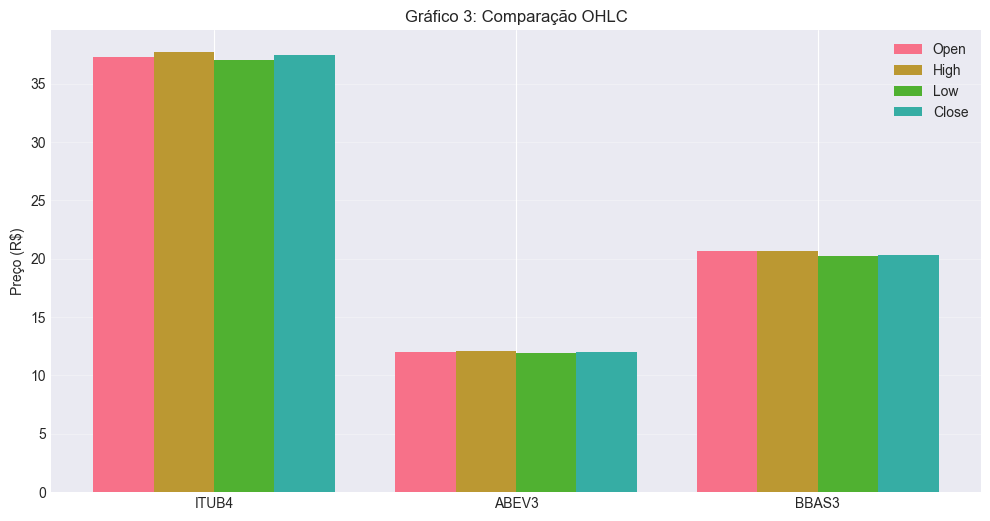

In [13]:
from io import StringIO
import seaborn as sns
acoes = ['ITUB4', 'ABEV3', 'BBAS3']

compilada = pd.DataFrame()

for acao in acoes:
    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={acao}.SAO&apikey={key}&datatype=csv'
    r = requests.get(url)
    tabela = pd.read_csv(StringIO(r.text))
    lista_tabelas = [compilada, tabela]
    compilada = pd.concat(lista_tabelas)
    

# Resetar índice
compilada = compilada.reset_index(drop=True)


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# Converter para numérico
compilada['volume'] = pd.to_numeric(compilada['volume'])
compilada['changePercent'] = pd.to_numeric(compilada['changePercent'].str.rstrip('%'))

# Nome da ação
compilada['acao'] = compilada['symbol'].str.replace('.SAO', '')

display(compilada)

# ==============================================
# GRÁFICO 5: Volume vs Variação %
# ==============================================

plt.figure(figsize=(10, 6))

plt.scatter(compilada['volume'] / 1_000_000, 
           compilada['changePercent'], 
           s=200, 
           c=['blue', 'green', 'orange'])

# Adicionar nomes das ações
for i, row in compilada.iterrows():
    plt.text(row['volume'] / 1_000_000, row['changePercent'], 
            row['acao'], fontsize=12, ha='center')

plt.xlabel('Volume (Milhões)')
plt.ylabel('Variação %')
plt.title('Gráfico 5: Volume vs Variação %')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.savefig('grafico_5.png')
plt.show()

# ==============================================
# GRÁFICO 3: OHLC Comparação
# ==============================================
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(compilada))
width = 0.2

ax.bar([i-1.5*width for i in x], compilada['open'], width, label='Open')
ax.bar([i-0.5*width for i in x], compilada['high'], width, label='High')
ax.bar([i+0.5*width for i in x], compilada['low'], width, label='Low')
ax.bar([i+1.5*width for i in x], compilada['price'], width, label='Close')

ax.set_xticks(x)
ax.set_xticklabels(compilada['acao'])
ax.set_ylabel('Preço (R$)')
ax.set_title('Gráfico 3: Comparação OHLC')
ax.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('grafico_3.png')
plt.show()

### Encontrar ativos

In [14]:
url = f'https://www.alphavantage.co/query?function=SYMBOL_SEARCH&keywords=amazon&apikey={key}&datatype=csv'
r = requests.get(url)

tabela = pd.read_csv(StringIO(r.text))
display(tabela)

,symbol,name,type,region,marketOpen,marketClose,timezone,currency,matchScore
0,AMZN,Amazon.com Inc,Equity,United States,09:30,16:00,UTC-04,USD,0.8000
1,ZAMZ.TRT,Amazon (AMZN) BMO CDR (CAD Hedged),Equity,Toronto,09:30,16:00,UTC-05,CAD,0.6154
2,AMZN.TRT,Amazon.com CDR (CAD Hedged),Equity,Toronto,09:30,16:00,UTC-05,CAD,0.6154
3,AMZ.DEX,Amazon.com Inc,Equity,XETRA,08:00,20:00,UTC+02,EUR,0.6000
4,AMZ.FRK,Amazon.com Inc,Equity,Frankfurt,08:00,20:00,UTC+02,EUR,0.6000
5,AMZO34.SAO,Amazon.com Inc,Equity,Brazil/Sao Paolo,10:00,17:30,UTC-03,BRL,0.6000
6,0R1O.LON,Amazon.com Inc.,Equity,United Kingdom,08:00,16:30,UTC+01,USD,0.5714
7,AMZ1.FRK,AMAZON.COM INC.CDR DL-01,Equity,Frankfurt,08:00,20:00,UTC+02,EUR,0.5000
8,AZFL,Amazonas Florestal Ltd,Equity,United States,09:30,16:00,UTC-04,USD,0.4286


### Informações de Resultado

In [15]:
url = f'https://www.alphavantage.co/query?function=EARNINGS&symbol=AMZN&apikey={key}'
r = requests.get(url)
data = r.json()

print(data)

{'symbol': 'AMZN', 'annualEarnings': [{'fiscalDateEnding': '2025-09-30', 'reportedEPS': '3.27'}, {'fiscalDateEnding': '2024-12-31', 'reportedEPS': '5.53'}, {'fiscalDateEnding': '2023-12-31', 'reportedEPS': '2.9'}, {'fiscalDateEnding': '2022-12-31', 'reportedEPS': '0.97'}, {'fiscalDateEnding': '2021-12-31', 'reportedEPS': '2.15'}, {'fiscalDateEnding': '2020-12-31', 'reportedEPS': '2.09'}, {'fiscalDateEnding': '2019-12-31', 'reportedEPS': '1.14'}, {'fiscalDateEnding': '2018-12-31', 'reportedEPS': '1'}, {'fiscalDateEnding': '2017-12-31', 'reportedEPS': '0.23'}, {'fiscalDateEnding': '2016-12-31', 'reportedEPS': '0.25'}, {'fiscalDateEnding': '2015-12-31', 'reportedEPS': '0.06'}, {'fiscalDateEnding': '2014-12-31', 'reportedEPS': '-0.03'}, {'fiscalDateEnding': '2013-12-31', 'reportedEPS': '-0.07'}, {'fiscalDateEnding': '2012-12-31', 'reportedEPS': '0.02'}, {'fiscalDateEnding': '2011-12-31', 'reportedEPS': '0.07'}, {'fiscalDateEnding': '2010-12-31', 'reportedEPS': '0.13'}, {'fiscalDateEnding':